In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader

In [6]:
df = pd.read_csv("fmnist_small.csv")

In [7]:
df.sample(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
3089,0,0,0,0,0,0,0,0,0,0,...,66,49,12,0,0,0,0,0,0,0
3100,3,0,0,0,0,0,0,0,0,0,...,118,73,0,0,0,0,0,0,0,0
965,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3955,4,0,0,0,0,0,0,0,0,0,...,0,0,93,112,52,0,0,0,0,0
5093,3,0,0,0,0,0,0,0,0,0,...,123,186,27,0,0,0,0,0,0,0
1778,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1562,6,0,0,0,0,0,0,0,4,2,...,0,0,0,0,93,99,75,0,0,0
4855,6,0,0,0,0,0,0,0,2,1,...,73,0,1,0,0,0,0,0,0,0
1587,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4738,3,0,0,0,0,0,0,0,0,0,...,134,30,0,0,0,0,0,0,0,0


In [8]:
torch.manual_seed(42)

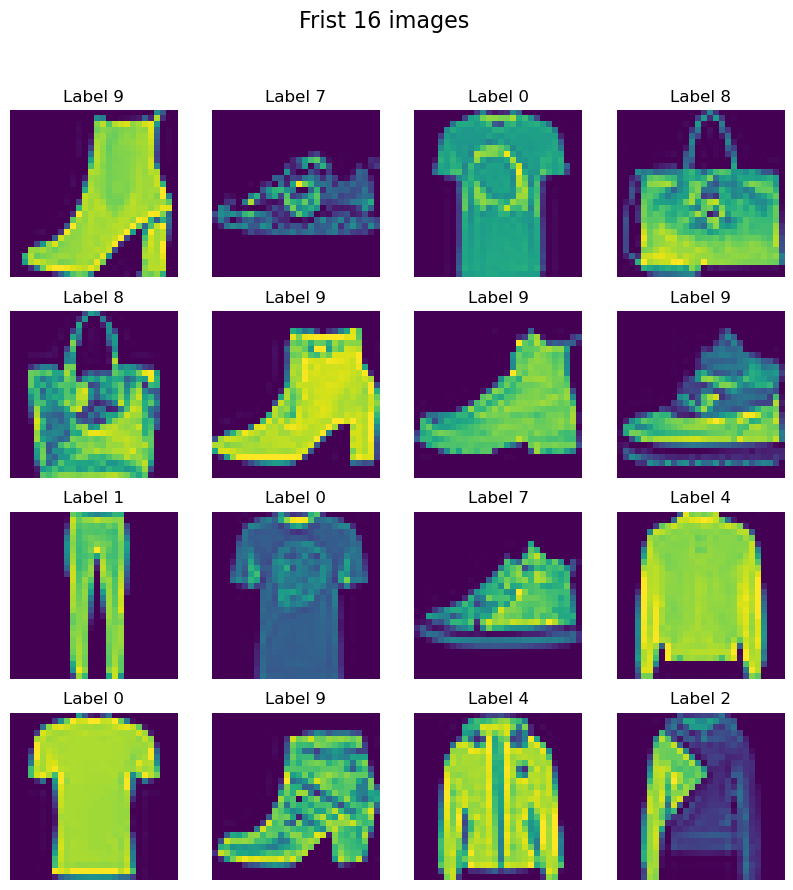

In [9]:
fig,axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("Frist 16 images", fontsize =16)

for i, ax in enumerate(axes.flat):
  img =df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis("off")

  ax.set_title(f"Label {df.iloc[i,0]}")

# Train Test split

In [10]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train = X_train/255.0     # Normalization steps basically amder pixel gula ke 0 thke 1 ar modde ante hobe tai 255 diye vag kora
X_test = X_test/255.0

In [13]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
3897,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5628,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.003922,...,0.356863,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1756,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2346,0.0,0.0,0.0,0.0,0.0,0.003922,0.000000,0.000000,0.0,0.000000,...,0.003922,0.000000,0.000000,0.000000,0.000000,0.254902,0.090196,0.000000,0.0,0.0
2996,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.262745,...,0.533333,0.470588,0.286275,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5191,0.0,0.0,0.0,0.0,0.0,0.000000,0.003922,0.000000,0.0,0.200000,...,0.000000,0.000000,0.003922,0.000000,0.031373,0.258824,0.000000,0.000000,0.0,0.0
5226,0.0,0.0,0.0,0.0,0.0,0.000000,0.011765,0.003922,0.0,0.000000,...,0.439216,0.474510,0.474510,0.027451,0.000000,0.003922,0.000000,0.000000,0.0,0.0
5390,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


# Custom Dataset

In [14]:
class CustomDataset(Dataset):

  def __init__(self,features,labels):

    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self,index):
    return self.features[index], self.labels[index]

In [15]:
train_dataset = CustomDataset(X_train.values,y_train.values)
len(train_dataset)

4800

In [16]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [17]:
test_dataset = CustomDataset(X_test.values , y_test.values)

In [18]:
len(test_dataset)

1200

# Create the DataLoader

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

# Define NN classes

In [20]:
class MyNN(nn.Module):

  def __init__(self,num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),

        nn.Linear(128,64),
        nn.ReLU(),

        nn.Linear(64,10),
        nn.ReLU()

    )

  def forward(self,X):
    return self.model(X)

# Epochs and Learning Rate

In [21]:
epochs = 100
learning_rate = 0.1

In [22]:
model = MyNN(X_train.shape[1])

In [23]:
#Loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer =optim.SGD(model.parameters(),lr = learning_rate)

# Training Loop

In [24]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:
    #forward pass
    outputs = model(batch_features)

    #loss calculation
    loss = criterion(outputs,batch_labels)
    #back pass
    optimizer.zero_grad()
    loss.backward()
    #gradient update
    optimizer.step()

    total_epoch_loss =  total_epoch_loss + loss.item()

  avg_epoch_lost = total_epoch_loss / len(train_loader)

  print(f"Epoch : {epoch + 1}, Loss: {avg_epoch_lost}")

Epoch : 1, Loss: 1.8937264060974122
Epoch : 2, Loss: 1.4182850527763367
Epoch : 3, Loss: 1.2588647790749867
Epoch : 4, Loss: 1.2074810616175333
Epoch : 5, Loss: 1.158756815592448
Epoch : 6, Loss: 1.137023729880651
Epoch : 7, Loss: 1.117131338516871
Epoch : 8, Loss: 1.087377720673879
Epoch : 9, Loss: 1.0766500194867452
Epoch : 10, Loss: 1.0635519236326219
Epoch : 11, Loss: 1.045787216424942
Epoch : 12, Loss: 1.037663832505544
Epoch : 13, Loss: 1.0216535238424937
Epoch : 14, Loss: 1.02518583714962
Epoch : 15, Loss: 0.9931821610530217
Epoch : 16, Loss: 0.9278847414255142
Epoch : 17, Loss: 0.8088102352619171
Epoch : 18, Loss: 0.7951250959436099
Epoch : 19, Loss: 0.7761318667729695
Epoch : 20, Loss: 0.7560314637422562
Epoch : 21, Loss: 0.7482242981592814
Epoch : 22, Loss: 0.7417934443553289
Epoch : 23, Loss: 0.731467724442482
Epoch : 24, Loss: 0.7229241601626079
Epoch : 25, Loss: 0.7145658165216446
Epoch : 26, Loss: 0.7103451144695282
Epoch : 27, Loss: 0.6967193336288134
Epoch : 28, Loss: 0

# Model evaluation

In [25]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
    (5): ReLU()
  )
)

In [26]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs,1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

print(f"Accuracy : {correct/total}")



Accuracy : 0.6658333333333334


In [27]:
model.eval()

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)

        for i in range(len(batch_labels)):
            print(
                f"Predicted: {predicted[i].item()} | "
                f"Actual: {batch_labels[i].item()}"
            )

        break

Predicted: 0 | Actual: 7
Predicted: 0 | Actual: 0
Predicted: 5 | Actual: 5
Predicted: 6 | Actual: 6
Predicted: 3 | Actual: 3
Predicted: 2 | Actual: 8
Predicted: 5 | Actual: 5
Predicted: 4 | Actual: 4
Predicted: 9 | Actual: 9
Predicted: 0 | Actual: 7
Predicted: 0 | Actual: 0
Predicted: 6 | Actual: 6
Predicted: 4 | Actual: 4
Predicted: 0 | Actual: 0
Predicted: 5 | Actual: 5
Predicted: 1 | Actual: 1
Predicted: 0 | Actual: 7
Predicted: 0 | Actual: 5
Predicted: 6 | Actual: 6
Predicted: 0 | Actual: 0
Predicted: 4 | Actual: 4
Predicted: 0 | Actual: 6
Predicted: 2 | Actual: 2
Predicted: 0 | Actual: 0
Predicted: 9 | Actual: 9
Predicted: 6 | Actual: 0
Predicted: 9 | Actual: 9
Predicted: 4 | Actual: 3
Predicted: 0 | Actual: 0
Predicted: 1 | Actual: 1
Predicted: 5 | Actual: 5
Predicted: 6 | Actual: 6
